In [1]:
import os 
import torch 
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from dataset import DroneFaceDataset, get_embedding
from model import Embeddinghead, ArcFaceLoss


c:\Users\Shamm\anaconda33\envs\droneface2\lib\site-packages\mtcnn\mtcnn.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os
import shutil
import random
from PIL import Image
from deepface import DeepFace 
import numpy as np
from torch.utils.data import Dataset 
import torchvision.transforms as transforms

sources = ["open_data_set\photos_all_faces",
           "open_data_set\portraits",
           "open_data_set\\trio_gp",
           "open_data_set\\trio_cam"]

destination = "combined_dataset"
os.makedirs(destination, exist_ok=True)

for source in sources:
    for filename in os.listdir(source):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            src_path = os.path.join(source, filename)
            dst_path = os.path.join(destination, filename)
            shutil.copy(src_path, dst_path)

print("all images combined successfully")



source = "combined_dataset"
destination = "prepared"

os.makedirs(destination, exist_ok=True)

for filename in os.listdir(source):
    if filename.lower().endswith((".jpg", ".png", "jpeg")):
        identity = filename[0].upper()
        identity_folder = os.path.join(destination, identity)
        os.makedirs(identity_folder, exist_ok=True)
        src_path = os.path.join(source, filename)
        dst_path = os.path.join(identity_folder, filename)
        shutil.move(src_path, dst_path)

print("Data split by identity")


source = "prepared"
base_split = "split" 

#splitting ids into training, validation, and testing
train_ids = ["A", "B", "C", "D", "E", "F", "G", "H"] #70% Training
val_ids = ["I"] #10% validation
test_ids = ["J", "K"] #20% testing


for split, ids in [("train", train_ids), ("validation", val_ids), ("test", test_ids)]:
    for identity in ids: 
        src = os.path.join(source, identity)
        dst = os.path.join(base_split, split, identity)
        os.makedirs(dst, exist_ok=True)
        for file in os.listdir(src):
            shutil.copy(os.path.join(src, file),
                        os.path.join(dst, file))
            
print("identity disjoint split completed")


all images combined successfully
Data split by identity
identity disjoint split completed


In [3]:
#settings 
DEEPFACE_MODEL = "DeepFace"
Detector = "retineface"
Embedding_dim = 512
head_dim = 256
batch_Size = 32 
epochs = 30
lr = 1e-3 #learning rate 
threshold = 0.45 #above threshold:more confident, below  threshold=less confident

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using: {device}")


Using: cpu


In [4]:
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

#dataset loading
train_set = DroneFaceDataset("split\\train", augment=True)
validation_set = DroneFaceDataset("split\\validation", augment=False)
test_set = DroneFaceDataset("split\\test", augment=False)

num_classes = len(train_set.classes)
idx_to_class= {idx:name for name, idx in train_set.class_to_idx.items()}



**Extracting Embeddings**

In [5]:
if os.path.exists("cache_train_embeddings.npy"):
    print("loading train embeddings")
    train_embeddings = np.load("cache_train_embeddings.npy")
    train_labels = np.load("cache_train_labels.npy")
else: 
    print("extracting")
    train_embeddings, train_labels = [], []

    for identity in train_set.classes:
        folder= os.path.join("split", "train", identity)
        for filename in os.listdir(folder):
            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            embedding = get_embedding(os.path.join(folder, filename))
            if embedding is not None:
                train_embeddings.append(embedding)
                train_labels.append(train_set.class_to_idx[identity])
            else:
                print("FAILED:", filename)
        print("processing:", filename)
    train_embeddings = np.array(train_embeddings)
    train_labels = np.array(train_labels)
    np.save("cache_train_embeddings.npy", train_embeddings)
    np.save("cache_train_labels.npy", train_labels)

if os.path.exists("cache_validation_embeddings.npy"):
    print("loading validation embeddings")
    validation_embeddings = np.load("cache_validation_embeddings.npy")
    validation_labels = np.load("cache_validation_labels.npy")
else: 
    print("extracting")
    validation_embeddings, validation_labels = [], []

    for identity in validation_set.classes:
        folder= os.path.join("split", "validation", identity)
        for filename in os.listdir(folder):
            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            embedding = get_embedding(os.path.join(folder, filename))
            if embedding is not None:
                validation_embeddings.append(embedding)
                validation_labels.append(validation_set.class_to_idx[identity])

validation_embeddings = np.array(validation_embeddings)
validation_labels = np.array(validation_labels)
np.save("cache_validation_embeddings.npy", validation_embeddings)
np.save("cache_validation_labels.npy", validation_labels)

train_embeddings_tensor = torch.tensor(train_embeddings, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
validation_embeddings_tensor = torch.tensor(validation_embeddings, dtype=torch.float32)
validation_labels_tensor = torch.tensor(validation_labels, dtype=torch.long)


loading train embeddings
loading validation embeddings


In [6]:
print("Train embeddings shape:", train_embeddings_tensor.shape)
print("Train labels shape:", train_labels_tensor.shape)
print("Validation embeddings shape:", validation_embeddings_tensor.shape)
print("Validation labels shape:", validation_labels_tensor.shape)

Train embeddings shape: torch.Size([1044, 512])
Train labels shape: torch.Size([1044])
Validation embeddings shape: torch.Size([131, 512])
Validation labels shape: torch.Size([131])


**Model Set up**

In [7]:
head = Embeddinghead().to(device)
arcface = ArcFaceLoss(in_features=head_dim, num_classes=num_classes).to(device)


optimizer = torch.optim.Adam([{'params': filter(lambda p: p.requires_grad, head.parameters()), 'lr': lr},
                              {'params': arcface.parameters(), 'lr': lr}])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)



**Training Set up**

In [8]:
embedding_loader = DataLoader(TensorDataset(train_embeddings_tensor, train_labels_tensor),
                              batch_size=batch_Size,
                              shuffle=True)

history = {'train_loss': [],
           'val_acc': []}

best_valacc = 0.0

for epoch in range(30):

    head.train()
    arcface.train()
    total_loss = 0.0

    for embeddings, labels in embedding_loader:
        embeddings=embeddings.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        proj = head(embeddings) #compresses from 4096 to 256
        logits = arcface(proj, labels)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss +=loss.item()
    scheduler.step()
    #building gallery
    head.eval()
    embeddings_gallery, labels_gallery = [], []
    with torch.no_grad():
        for emb_g, labels_g in DataLoader(TensorDataset(train_embeddings_tensor, train_labels_tensor), batch_size=batch_Size, shuffle=False):
            embeddings_gallery.append(head(emb_g.to(device)).cpu())
            labels_gallery.append(labels_g)
    embeddings_gallery = torch.cat(embeddings_gallery)
    labels_gallery = torch.cat(labels_gallery)

    #validation accuracy using cosine similarity (Different people)
    val_proj = []
    val_labels_l = [] 
    with torch.no_grad():
        for embeddings, labels in DataLoader(TensorDataset(validation_embeddings_tensor, validation_labels_tensor), batch_size=batch_Size, shuffle=False):
            val_proj.append(head(embeddings.to(device)).cpu())
            val_labels_l.append(labels)
        val_proj = torch.cat(val_proj)
        val_labels_l = torch.cat(val_labels_l)
    correct= 0
    total=0
    for i in range(len(val_proj)):
        for j in range(i+1, len(val_proj)):
            similarities = F.cosine_similarity(val_proj[i].unsqueeze(0), val_proj[j].unsqueeze(0))
            same_person = (val_labels_l[i].item() == val_labels_l[j].item())
            predicted_S = similarities >= threshold
            if predicted_S == same_person:
               correct +=1
            total +=1
    validation_accuracy = 100 * correct / total 
    history['val_acc'].append(validation_accuracy)             
    avg_loss = total_loss/ len(embedding_loader)
    history['train_loss'].append(avg_loss)
    #to save best model 
    if epoch > 0:
        if validation_accuracy > best_valacc:
            best_valacc = validation_accuracy
            torch.save({'head': head.state_dict(), 'arcface': arcface.state_dict(), "epoch": epoch + 1}, "best_model.pth")
            print("best model saved")
            saved = "Saved"
        else: 
            saved = ""
    print(f"Epoch: {epoch+1}    Loss: {total_loss:.4f}    Validation Accuracy: {validation_accuracy:.2f}%")
    print(f" Best Validation Accuracy: {best_valacc:.2f}%")

   
    
print(f"Best validation accuracy: {best_valacc:.2f}%") 

Epoch: 1    Loss: 406.2277    Validation Accuracy: 99.91%
 Best Validation Accuracy: 0.00%
best model saved
Epoch: 2    Loss: 223.9540    Validation Accuracy: 73.75%
 Best Validation Accuracy: 73.75%
Epoch: 3    Loss: 172.6205    Validation Accuracy: 71.32%
 Best Validation Accuracy: 73.75%
best model saved
Epoch: 4    Loss: 150.2385    Validation Accuracy: 79.11%
 Best Validation Accuracy: 79.11%
Epoch: 5    Loss: 149.7512    Validation Accuracy: 76.79%
 Best Validation Accuracy: 79.11%
Epoch: 6    Loss: 134.1869    Validation Accuracy: 70.62%
 Best Validation Accuracy: 79.11%
best model saved
Epoch: 7    Loss: 140.0372    Validation Accuracy: 82.83%
 Best Validation Accuracy: 82.83%
Epoch: 8    Loss: 101.5951    Validation Accuracy: 68.04%
 Best Validation Accuracy: 82.83%
Epoch: 9    Loss: 92.5467    Validation Accuracy: 76.42%
 Best Validation Accuracy: 82.83%
Epoch: 10    Loss: 91.0980    Validation Accuracy: 74.03%
 Best Validation Accuracy: 82.83%
Epoch: 11    Loss: 88.2266    V

In [9]:
# Check if a validation image is identical to a training image
sim = F.cosine_similarity(validation_embeddings_tensor[0].unsqueeze(0), train_embeddings_tensor)
print(f"Max similarity between Val[0] and Train set: {sim.max().item():.4f}")
# If this is > 0.99, you have data leakage.

Max similarity between Val[0] and Train set: 0.6121


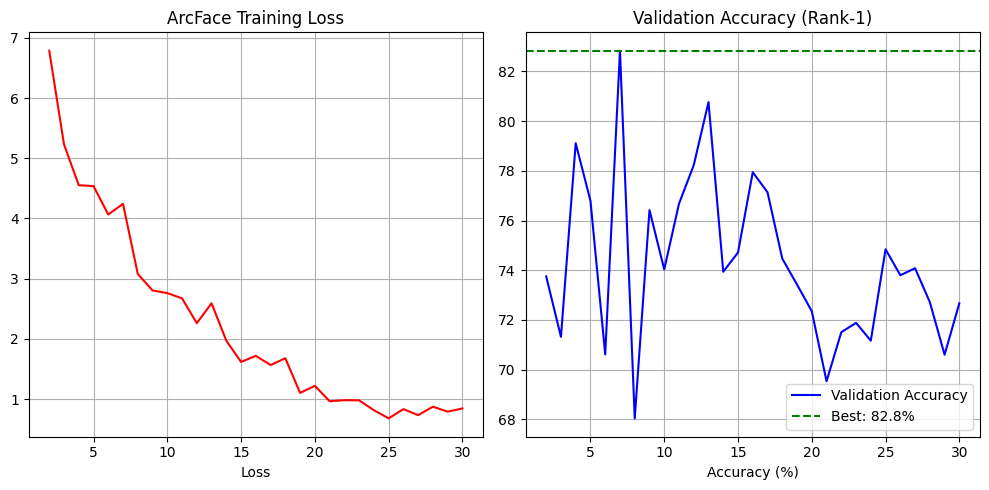

In [10]:
import matplotlib.pyplot as plt

#show real performance from epoch 2 onwards. as first epoch is from pretrained-base
epochs_to_show = range(2, len(history['train_loss']) + 1)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(epochs_to_show, (history['train_loss'][1:]), 'r' , label='Train Loss')
plt.title('ArcFace Training Loss')
plt.xlabel('Epochs')
plt.xlabel('Loss')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_to_show, history['val_acc'][1:], 'b-', label='Validation Accuracy')
plt.axhline(y=best_valacc, color='g', linestyle= '--', label=f'Best: {best_valacc:.1f}%')
plt.title('Validation Accuracy (Rank-1)')
plt.xlabel('Epochs')
plt.xlabel('Accuracy (%)')
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.savefig('training_progress.png')

**Testing the model**

In [11]:
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, classification_report)


#loading the best saved model
checkpoint =torch.load("best_model.pth", map_location=device)
head.load_state_dict(checkpoint["head"])
head.eval()

test_gal_embeddings, test_gal_labels = [], [] 
test_query_embeddings, test_query_labels = [], []
top1 = top5 = total = 0


for identity in test_set.classes: 
    folder = os.path.join("split", "test", identity)
    true_label = test_set.class_to_idx[identity]
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png")) ])
    mid = len(files) // 2
    gallery_files = files[:mid]
    query_files = files[mid:]

    for filename in gallery_files:
        embedding = get_embedding(os.path.join(folder, filename))
        if embedding is None: 
            continue
        tensor = torch.tensor(embedding, dtype = torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            proj = head(tensor).cpu().squeeze(0)
        test_gal_embeddings.append(proj)
        test_gal_labels.append(true_label)
    for filename in query_files:
        embedding = get_embedding(os.path.join(folder, filename))
        if embedding is None: 
            continue
        tensor = torch.tensor(embedding, dtype = torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            proj = head(tensor).cpu().squeeze(0)
        test_query_embeddings.append(proj)
        test_query_labels.append(true_label)
test_gal_embeddings = torch.stack(test_gal_embeddings)
test_gal_labels = torch.tensor(test_gal_labels)
test_query_labels = torch.tensor(test_query_labels)

top1 = top5 = total = 0
rank1_preds = []
for i in range(len(test_query_embeddings)):
   similarities = F.cosine_similarity(test_query_embeddings[i].unsqueeze(0), test_gal_embeddings)

   top5_idx = torch.topk(similarities, k=min(5, len(test_gal_embeddings))).indices
   predicted_label = test_gal_labels[top5_idx[0]].item()
   rank1_preds.append(predicted_label)

   if predicted_label == test_query_labels[i].item():
            top1 +=1
   if test_query_labels[i].item() in [test_gal_labels[j].item() for j in top5_idx]:
            top5 +=1
   total +=1

print(f"Rank 1 Accuracy: {100*top1/total:.2f}%")
print(f"Rank 5 Accuracy: {100*top5/total:.2f}%"
      )

rank1_predictions = np.array(rank1_preds)
query_labels_np= test_query_labels.numpy()

precision = precision_score(query_labels_np, rank1_predictions, average="macro", zero_division=0)
recall = recall_score(query_labels_np, rank1_predictions, average="macro", zero_division=0)
f1_Score = f1_score(query_labels_np, rank1_predictions, average="macro", zero_division=0)


print(f"Precision(macro): {precision:.4f}")
print(f"Recall(macro): {recall:.4f}")
print(f"F1 Score(macro): {f1_Score:.4f}")



Rank 1 Accuracy: 79.55%
Rank 5 Accuracy: 97.73%
Precision(macro): 0.7961
Recall(macro): 0.7955
F1 Score(macro): 0.7953


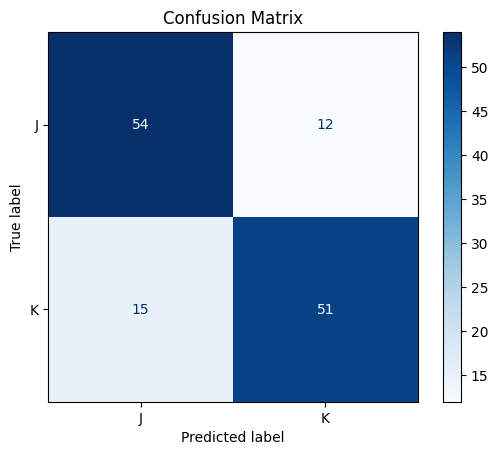

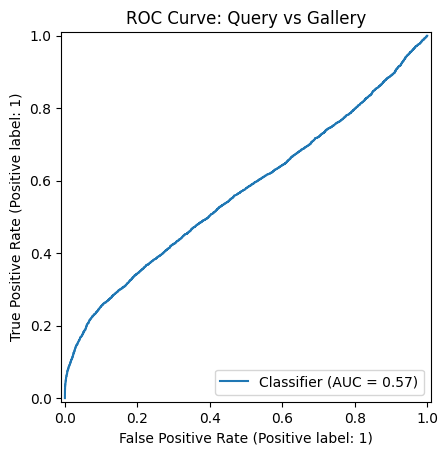

In [12]:
#Confusion Matrix
identity_names = [test_set.classes[l] for l in sorted(set(query_labels_np))]
confusion_mat = confusion_matrix(query_labels_np, rank1_predictions)
display = ConfusionMatrixDisplay(confusion_mat, display_labels=identity_names)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("ConfusionMatrix.png", dpi=150, bbox_inches="tight")
plt.show()


#AUC Curve

y_true_pairs, y_scores_pairs = [] , []
for i in range(len(test_query_embeddings)):
    for j in range(len(test_gal_embeddings)):
        similarities = F.cosine_similarity(test_query_embeddings[i].unsqueeze(0), test_gal_embeddings[j].unsqueeze(0))
        same_person = int(test_query_labels[i].item() == test_gal_labels[j].item())
        y_true_pairs.append(same_person)
        y_scores_pairs.append(similarities)
auc = roc_auc_score(y_true_pairs, y_scores_pairs)

RocCurveDisplay.from_predictions(y_true_pairs, y_scores_pairs)
plt.title("ROC Curve: Query vs Gallery")
plt.savefig("roc_curve", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
report = classification_report(query_labels_np, rank1_predictions, target_names=identity_names)
with open("classification_report.txt", "w") as f:
    f.write(report)


print(report)


              precision    recall  f1-score   support

           J       0.78      0.82      0.80        66
           K       0.81      0.77      0.79        66

    accuracy                           0.80       132
   macro avg       0.80      0.80      0.80       132
weighted avg       0.80      0.80      0.80       132



In [14]:
#testing on a single image

def recognize_image(img_path):
    embedding = get_embedding(img_path)
    if embedding is None:
        print("No face found")
        return
    embedding_tensor = torch.tensor(embedding, dtype = torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        proj = head(embedding_tensor).cpu().squeeze(0)
    similarities = F.cosine_similarity(proj.unsqueeze(0), embeddings_gallery)
    top5_idx = torch.topk(similarities, k=5).indices

    best_score = similarities[top5_idx[0]].item()
    best_name = idx_to_class[labels_gallery[top5_idx[0]].item()]
    predicted = best_name if best_score >= threshold else "unknown"

    print(f"Predicted: {predicted} score: {best_score:.4f}")
    for i, idx in enumerate(top5_idx, 1):
        name = idx_to_class[labels_gallery[idx].item()]
        score = similarities[idx].item()
        print(f"{i} {name} {score:.4f}")

**Testing on BirdsEye-RU dataset**


In [15]:
import pandas as pd 


ROOT_DIR = "BirdsEye-RU_final\\"
META_PATH = os.path.join(ROOT_DIR, "db_info.csv")
df = pd.read_csv(META_PATH)
identities = sorted(list(set(f.split('/')[-1].split('.')[0] for f in df['image_path'].values)))
id_to_idx = {name: i for i, name in enumerate(identities)} 
print(f"Total identities: {len(identities)}")


Total identities: 2978


In [16]:
import pandas as pd
from torch.utils.data import DataLoader



# Create unique IDs for all 2,978 individuals
df['unique_id'] = df['image_path'].apply(lambda x: x.split('/')[-1].split('.')[0])
all_ids = sorted(df['unique_id'].unique())
num_classes = len(all_ids)

# Initialize the fixed datasets
train_dataset = birdsEyeDataset(df[df['split'] == 'train'], all_ids, augment=True)
val_dataset = birdsEyeDataset(df[df['split'] == 'val'], all_ids, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Ready to train with {num_classes} classes.")

NameError: name 'birdsEyeDataset' is not defined